In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm
from scipy.interpolate import griddata

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.stats import gaussian_kde
from scipy.ndimage.filters import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_9541/4184058898.py:31: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
file_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(file_dir+'galaxies_tng300_072_hmc_lensing_prof_types.txt','rb') as f:
    lensing_cat=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)
with open(file_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)
mask=(tab['proj']=='xy')
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [4]:
with open(file_dir+'galaxies_tng300_072_halo_complete_pos.txt','rb') as f:
    tab_pos=pickle.load(f)

In [5]:
with open(file_dir+'galaxies_tng300_072_hmc_mass_gap.txt','rb') as f:
    tab_mag=pickle.load(f)

In [6]:
def period_modify(x,period_box=205*1e3/1.4/0.6774):
    x=x-period_box*np.round(x/period_box)
    return x

In [7]:
tab_mag

mass_gap_13,mass_gap_14,mass_gap_15
float64,float64,float64
0.7080429293862558,0.8618000247231699,0.9905327059975839
0.8248484590563994,0.9349587419543486,1.0088189104113798
0.3626761863429451,0.5952630469996834,0.7039266059596443
0.9893898921819932,1.1078362422796495,1.1152644115301378
1.017331546112338,1.167778437897006,1.2171673233950528
0.3212443478336784,0.3971749432316276,1.0182543881168815
-0.021876229132212544,0.6187153922667132,0.7368432151426898
0.8892314847872829,0.89765242900115,0.9547822889254665
0.8701505177706803,0.9290704243868912,1.0146073811740006


In [8]:
def random_noise_on_richness(data,error=2,times=30):
    n=len(data)
    data0=np.asarray([[data]])
    for i in range(times):
        data0=np.append(data0,[[data+np.random.normal(loc=0,scale=error,size=n)]],axis=1)
    data1=data0[0].T
    data_mean=np.sum(data1,axis=1)/times
    return data_mean

In [9]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [10]:
with open(file_dir+'galaxies_tng300_072_halo_complete_R200.txt','rb') as f:
    tab_r200=pickle.load(f)

In [11]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]

In [12]:
dist_tab=np.sqrt(np.sum((np.asarray(tab_pos['SubHaloPos'])-np.asarray(tab_pos['SubhaloCM']))**2,axis=1))/tab_r200['Group_R_Crit200']

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_9541/1309049553.py:8: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


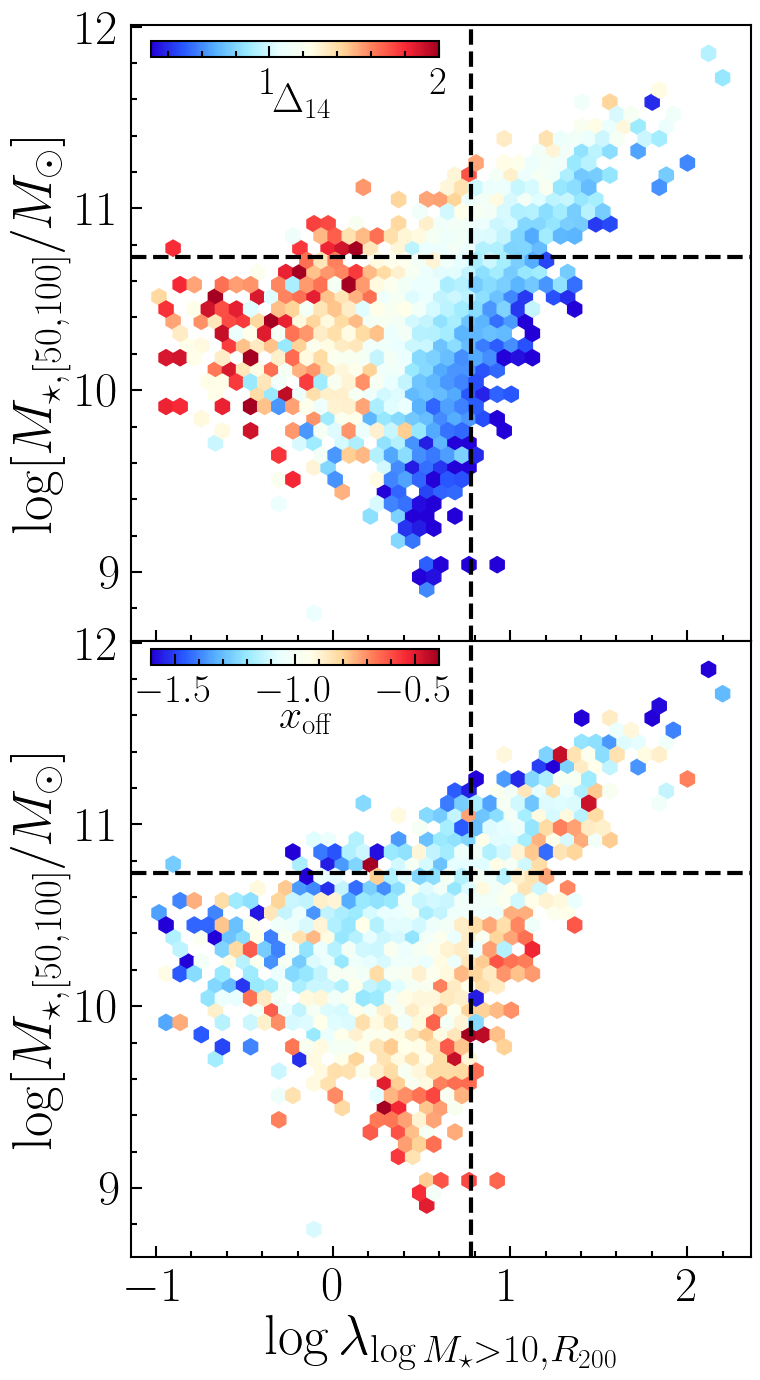

In [ ]:
name='richness_cut_r200_10'

top_numb=600
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])


fig=plt.figure(figsize=(8,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0)
ax1,ax2=gs.subplots(sharex='col')

label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_100_gal']-tab2[mask10]['aper_50_gal'])
zdata=tab_mag[mask10]['mass_gap_14']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0.3,vmax=2)

cax = fig.add_axes([0.15, 0.86, 0.36, 0.01])
ax1.text(0.23,0.86,r'$\Delta_{14}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=np.log10(dist_tab[mask10])
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=-1.6,vmax=-0.4)
ax2.text(0.24,0.86,r'$\log x_{\rm off}$',transform=ax2.transAxes,size=30)

#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.15, 0.48, 0.36, 0.01])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)
ax2.set_ylabel(r'$\log[M_{\star,[50,100]}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')

plt.savefig(fig_dir+"Fig14.pdf",dpi=150,bbox_inches='tight')

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_9541/3295675222.py:8: RuntimeWarning: divide by zero encountered in log10
  xdata0=np.log10(tab2[mask1][name])


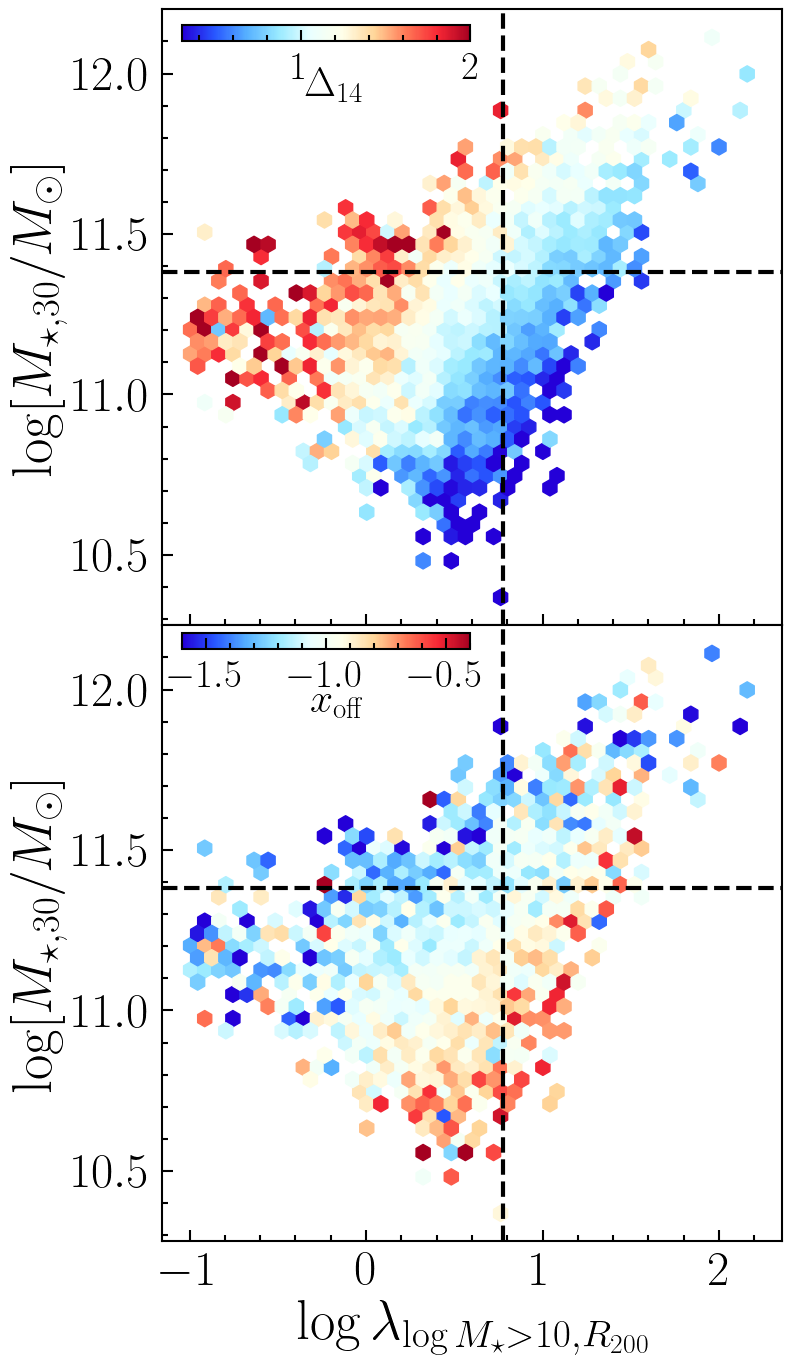

In [16]:
name='richness_cut_r200_10'

top_numb=600
mask1=(tab2['c_200c']<15)
ydata0=np.log10(tab2[mask1]['aper_30_gal'])
topNout=topNselect(tab2[mask1],'aper_30_gal',top_numb)
mask_l=(ydata0>=np.min(np.log10(topNout['aper_30_gal'])))
xdata0=np.log10(tab2[mask1][name])

mask_h1=(xdata0>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata0==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata0[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]

x_v=np.min(xdata0[mask_h])
y_v=np.min(ydata0[mask_l])


fig=plt.figure(figsize=(8,16))
gs = fig.add_gridspec(2,1, hspace=0, wspace=0)
ax1,ax2=gs.subplots(sharex='col')

label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
tab_x=random_noise_on_richness(tab2[name],error=1,times=10)
mask10=(tab2['c_200c']<15)&(tab_x>0.1)
xdata=np.log10(tab_x[mask10])
ydata=np.log10(tab2[mask10]['aper_30_gal'])
zdata=tab_mag[mask10]['mass_gap_14']
SC=ax1.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=0.3,vmax=2)

cax = fig.add_axes([0.15, 0.86, 0.36, 0.01])
ax1.text(0.23,0.86,r'$\Delta_{14}$',transform=ax1.transAxes,size=30)
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
zdata=np.log10(dist_tab[mask10])
SC=ax2.hexbin(xdata,ydata,C=zdata,cmap=cmap1,gridsize=40,vmin=-1.6,vmax=-0.4)
ax2.text(0.24,0.86,r'$x_{\rm off}$',transform=ax2.transAxes,size=30)

#SC=ax2.hexbin(xdata,ydata,mincnt=1,cmap='plasma',gridsize=40)
cax = fig.add_axes([0.15, 0.48, 0.36, 0.01])
cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)


cbar = plt.colorbar(SC, cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=28)
ax1.set_xlabel(label,fontsize=40)
ax2.set_xlabel(label,fontsize=40)
ax1.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)
ax2.set_ylabel(r'$\log[M_{\star,30}/M_\odot]$',fontsize=40)

ax1.axvline(x_v,c='black',lw=3,ls='--')
ax1.axhline(y_v,c='black',lw=3,ls='--')
ax2.axvline(x_v,c='black',lw=3,ls='--')
ax2.axhline(y_v,c='black',lw=3,ls='--')

In [22]:
top_10_indices = np.argsort(zdata)[-10:]
print(top_10_indices)

Group_R_Crit200
---------------
             78
           1530
            210
            141
            722
            758
            695
             19
            315
            639


In [23]:
tab2[78]

gal_num,proj,catgrp_id,mass_halo,aper_10_gal,aper_30_gal,aper_50_gal,aper_75_gal,aper_100_gal,aper_150_gal,c_200c,c_to_a_3d,b_to_a_3d,v_sigma_3d,acc_rate,r_20_gal,r_50_gal,r_80_gal,richness_cut_r200_8.5,richness_cut_r200_8.5_Q,richness_cut_r800k_8.5,richness_cut_r800k_8.5_Q,richness_cut_r200_10,richness_cut_r200_10_Q,richness_cut_r800k_10,richness_cut_r800k_10_Q,satellite_mass_cut_r200_8.5,satellite_mass_cut_r200_8.5_Q,satellite_mass_cut_r800k_8.5,satellite_mass_cut_r800k_8.5_Q,satellite_mass_cut_r200_10,satellite_mass_cut_r200_10_Q,satellite_mass_cut_r800k_10,satellite_mass_cut_r800k_10_Q,richness_cut_r200_8.5_xy_1,richness_cut_r200_8.5_xy_1_Q,richness_cut_r200_8.5_xy_3,richness_cut_r200_8.5_xy_3_Q,richness_cut_r200_8.5_xy_5,richness_cut_r200_8.5_xy_5_Q,richness_cut_r200_8.5_xy_10,richness_cut_r200_8.5_xy_10_Q,richness_cut_r200_8.5_xy_20,richness_cut_r200_8.5_xy_20_Q,richness_cut_r200_8.5_xy_40,richness_cut_r200_8.5_xy_40_Q,richness_cut_r200_8.5_xy_60,richness_cut_r200_8.5_xy_60_Q,satellite_mass_cut_r200_8.5_xy_1,satellite_mass_cut_r200_8.5_xy_1_Q,satellite_mass_cut_r200_8.5_xy_3,satellite_mass_cut_r200_8.5_xy_3_Q,satellite_mass_cut_r200_8.5_xy_5,satellite_mass_cut_r200_8.5_xy_5_Q,satellite_mass_cut_r200_8.5_xy_10,satellite_mass_cut_r200_8.5_xy_10_Q,satellite_mass_cut_r200_8.5_xy_20,satellite_mass_cut_r200_8.5_xy_20_Q,satellite_mass_cut_r200_8.5_xy_40,satellite_mass_cut_r200_8.5_xy_40_Q,satellite_mass_cut_r200_8.5_xy_60,satellite_mass_cut_r200_8.5_xy_60_Q,richness_cut_r200_10_xy_1,richness_cut_r200_10_xy_1_Q,richness_cut_r200_10_xy_3,richness_cut_r200_10_xy_3_Q,richness_cut_r200_10_xy_5,richness_cut_r200_10_xy_5_Q,richness_cut_r200_10_xy_10,richness_cut_r200_10_xy_10_Q,richness_cut_r200_10_xy_20,richness_cut_r200_10_xy_20_Q,richness_cut_r200_10_xy_40,richness_cut_r200_10_xy_40_Q,richness_cut_r200_10_xy_60,richness_cut_r200_10_xy_60_Q,satellite_mass_cut_r200_10_xy_1,satellite_mass_cut_r200_10_xy_1_Q,satellite_mass_cut_r200_10_xy_3,satellite_mass_cut_r200_10_xy_3_Q,satellite_mass_cut_r200_10_xy_5,satellite_mass_cut_r200_10_xy_5_Q,satellite_mass_cut_r200_10_xy_10,satellite_mass_cut_r200_10_xy_10_Q,satellite_mass_cut_r200_10_xy_20,satellite_mass_cut_r200_10_xy_20_Q,satellite_mass_cut_r200_10_xy_40,satellite_mass_cut_r200_10_xy_40_Q,satellite_mass_cut_r200_10_xy_60,satellite_mass_cut_r200_10_xy_60_Q,richness_cut_r200_8.5_yz_1,richness_cut_r200_8.5_yz_1_Q,richness_cut_r200_8.5_yz_3,richness_cut_r200_8.5_yz_3_Q,richness_cut_r200_8.5_yz_5,richness_cut_r200_8.5_yz_5_Q,richness_cut_r200_8.5_yz_10,richness_cut_r200_8.5_yz_10_Q,richness_cut_r200_8.5_yz_20,richness_cut_r200_8.5_yz_20_Q,richness_cut_r200_8.5_yz_40,richness_cut_r200_8.5_yz_40_Q,richness_cut_r200_8.5_yz_60,richness_cut_r200_8.5_yz_60_Q,satellite_mass_cut_r200_8.5_yz_1,satellite_mass_cut_r200_8.5_yz_1_Q,satellite_mass_cut_r200_8.5_yz_3,satellite_mass_cut_r200_8.5_yz_3_Q,satellite_mass_cut_r200_8.5_yz_5,satellite_mass_cut_r200_8.5_yz_5_Q,satellite_mass_cut_r200_8.5_yz_10,satellite_mass_cut_r200_8.5_yz_10_Q,satellite_mass_cut_r200_8.5_yz_20,satellite_mass_cut_r200_8.5_yz_20_Q,satellite_mass_cut_r200_8.5_yz_40,satellite_mass_cut_r200_8.5_yz_40_Q,satellite_mass_cut_r200_8.5_yz_60,satellite_mass_cut_r200_8.5_yz_60_Q,richness_cut_r200_10_yz_1,richness_cut_r200_10_yz_1_Q,richness_cut_r200_10_yz_3,richness_cut_r200_10_yz_3_Q,richness_cut_r200_10_yz_5,richness_cut_r200_10_yz_5_Q,richness_cut_r200_10_yz_10,richness_cut_r200_10_yz_10_Q,richness_cut_r200_10_yz_20,richness_cut_r200_10_yz_20_Q,richness_cut_r200_10_yz_40,richness_cut_r200_10_yz_40_Q,richness_cut_r200_10_yz_60,richness_cut_r200_10_yz_60_Q,satellite_mass_cut_r200_10_yz_1,satellite_mass_cut_r200_10_yz_1_Q,satellite_mass_cut_r200_10_yz_3,satellite_mass_cut_r200_10_yz_3_Q,satellite_mass_cut_r200_10_yz_5,satellite_mass_cut_r200_10_yz_5_Q,satellite_mass_cut_r200_10_yz_10,satellite_mass_cut_r200_10_yz_10_Q,satellite_mass_cut_r200_10_yz_20,satellite_mass_cut_r200_10_yz_20_Q,satellite_mass_cut_r200_10_yz_40,satellite_mass_cut_r200_10